In [23]:
# Import required libraries and load the IMDb 5000 dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/movie_metadata.csv')

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

Dataset loaded successfully!
Rows and Columns: (5043, 28)


In [24]:
# Display the first few rows of the dataset

df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [25]:
# Check the number of missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0].sort_values(ascending=False))

Missing values in each column:
gross                      884
budget                     492
aspect_ratio               329
content_rating             303
plot_keywords              153
title_year                 108
director_name              104
director_facebook_likes    104
num_critic_for_reviews      50
actor_3_name                23
actor_3_facebook_likes      23
num_user_for_reviews        21
color                       19
duration                    15
language                    14
actor_2_name                13
facenumber_in_poster        13
actor_2_facebook_likes      13
actor_1_facebook_likes       7
actor_1_name                 7
country                      5
dtype: int64


In [26]:
# Calculate the percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_table = missing_table[missing_table['Missing Values'] > 0]
missing_table = missing_table.sort_values('Percentage', ascending=False)

print(missing_table)

                         Missing Values  Percentage
gross                               884   17.529248
budget                              492    9.756098
aspect_ratio                        329    6.523895
content_rating                      303    6.008328
plot_keywords                       153    3.033908
title_year                          108    2.141582
director_name                       104    2.062265
director_facebook_likes             104    2.062265
num_critic_for_reviews               50    0.991473
actor_3_name                         23    0.456078
actor_3_facebook_likes               23    0.456078
num_user_for_reviews                 21    0.416419
color                                19    0.376760
duration                             15    0.297442
language                             14    0.277613
actor_2_name                         13    0.257783
facenumber_in_poster                 13    0.257783
actor_2_facebook_likes               13    0.257783
actor_1_face

In [27]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

Categorical columns:
['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'movie_title', 'actor_3_name', 'plot_keywords', 'movie_imdb_link', 'language', 'country', 'content_rating']


In [28]:
# Fill missing numerical values using the median

for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("Missing numerical values have been filled using the median.")

Missing numerical values have been filled using the median.


In [29]:
# Fill missing categorical values using the mode

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing categorical values have been filled using the mode.")

Missing categorical values have been filled using the mode.


In [30]:
# Check whether any missing values remain after imputation

remaining_missing = df.isnull().sum()

print("Remaining missing values:")
print(remaining_missing[remaining_missing > 0])

if remaining_missing.sum() == 0:
    print("\nNo missing values remain in the dataset.")

Remaining missing values:
Series([], dtype: int64)

No missing values remain in the dataset.


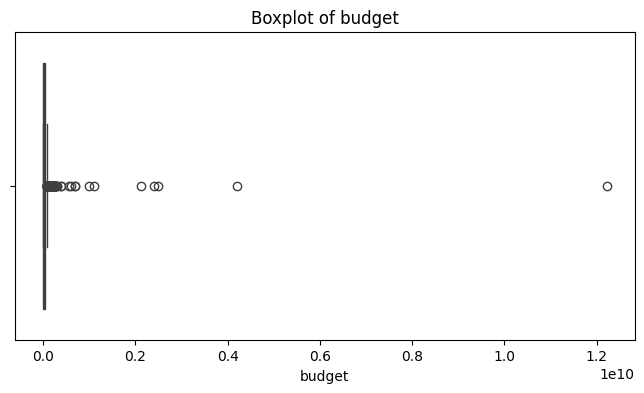

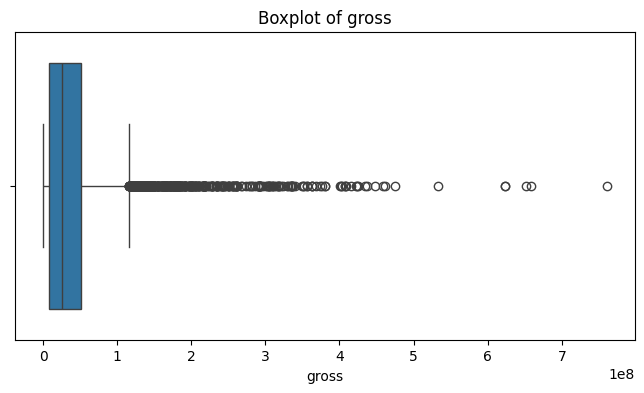

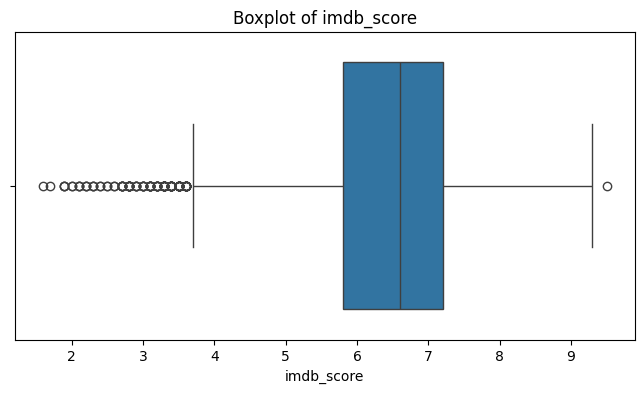

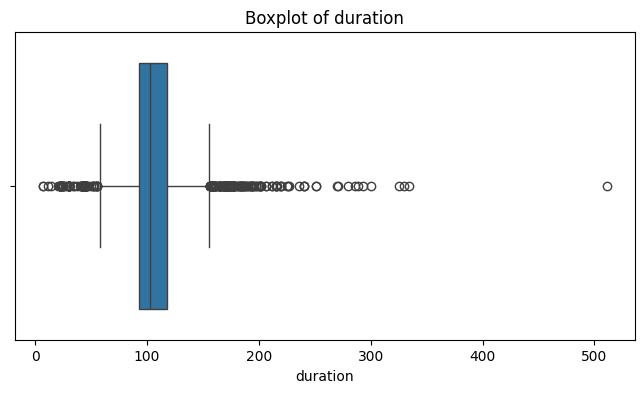

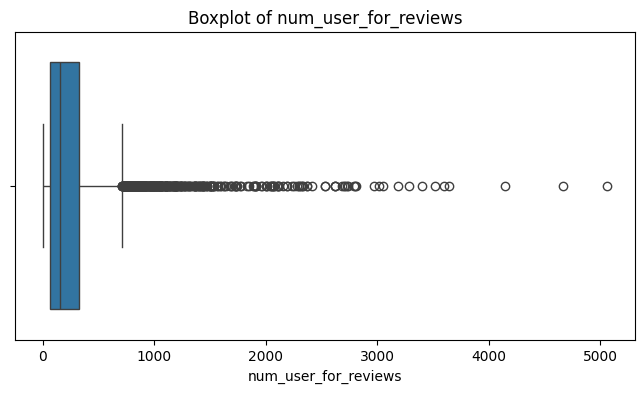

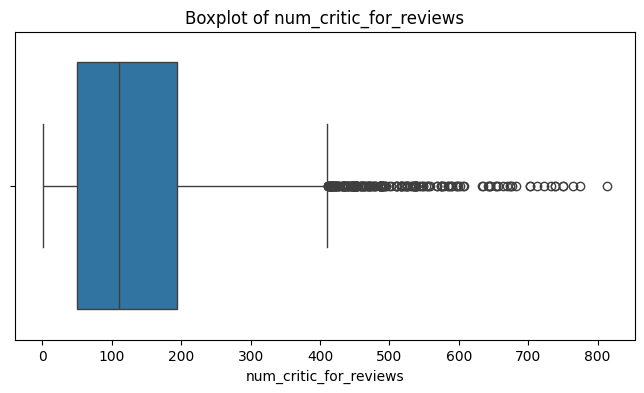

In [31]:
# Detect outliers using boxplots for important numerical features

columns_to_check = [
    'budget',
    'gross',
    'imdb_score',
    'duration',
    'num_user_for_reviews',
    'num_critic_for_reviews'
]

for column in columns_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [32]:
# Detect outliers using the Z-score method

from scipy.stats import zscore

zscore_columns = [
    'budget',
    'gross',
    'imdb_score',
    'duration',
    'num_user_for_reviews',
    'num_critic_for_reviews'
]

z_scores = df[zscore_columns].apply(zscore)

outlier_counts = (np.abs(z_scores) > 3).sum()

print("Number of potential outliers using Z-score > 3:")
print(outlier_counts)

Number of potential outliers using Z-score > 3:
budget                      9
gross                     119
imdb_score                 46
duration                   98
num_user_for_reviews      103
num_critic_for_reviews     81
dtype: int64


In [33]:
# Calculate the percentage of potential outliers in each selected column

outlier_percentage = (outlier_counts / len(df)) * 100

outlier_table = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier Percentage': outlier_percentage
})

print(outlier_table)

                        Outlier Count  Outlier Percentage
budget                              9            0.178465
gross                             119            2.359707
imdb_score                         46            0.912155
duration                           98            1.943288
num_user_for_reviews              103            2.042435
num_critic_for_reviews             81            1.606187


In [34]:
# Remove rows containing extreme outliers based on Z-score greater than 3

zscore_mask = (np.abs(z_scores) <= 3).all(axis=1)

df_cleaned = df[zscore_mask].copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_cleaned.shape)
print("Rows removed:", len(df) - len(df_cleaned))

Original dataset shape: (5043, 28)
Cleaned dataset shape: (4671, 28)
Rows removed: 372


In [35]:
# Check the final cleaned dataset

print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Final dataset shape: (5043, 28)

Missing values:
0

Duplicate rows:
45


In [36]:
# Save the cleaned dataset as a new CSV file

df.to_csv('/content/imdb_5000_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


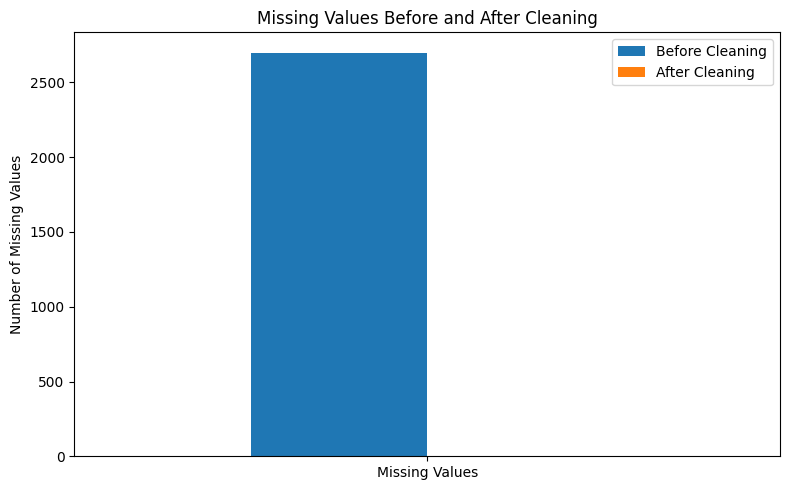

Missing values before cleaning: 2700
Missing values after cleaning: 0


In [39]:
# Visualize missing values before and after cleaning

original_df = pd.read_csv('/content/movie_metadata.csv')

# Count missing values before and after cleaning
missing_before = original_df.isnull().sum().sum()
missing_after = df.isnull().sum().sum()

# Create comparison data
comparison = pd.DataFrame({
    'Before Cleaning': [missing_before],
    'After Cleaning': [missing_after]
}, index=['Missing Values'])

# Plot
comparison.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Missing Values Before and After Cleaning')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print("Missing values before cleaning:", missing_before)
print("Missing values after cleaning:", missing_after)